
Top 15 Random Forest Features
                              Feature  Importance
15                   StockOptionLevel    0.071526
9                       MonthlyIncome    0.059532
8                     JobSatisfaction    0.055596
25  Department_Research & Development    0.047477
6                      JobInvolvement    0.044820
22               YearsWithCurrManager    0.041122
14           RelationshipSatisfaction    0.039483
7                            JobLevel    0.039042
4             EnvironmentSatisfaction    0.035910
41              MaritalStatus_Married    0.034703
16                  TotalWorkingYears    0.033986
19                     YearsAtCompany    0.033016
10                        MonthlyRate    0.031726
0                                 Age    0.030428
1                           DailyRate    0.030022


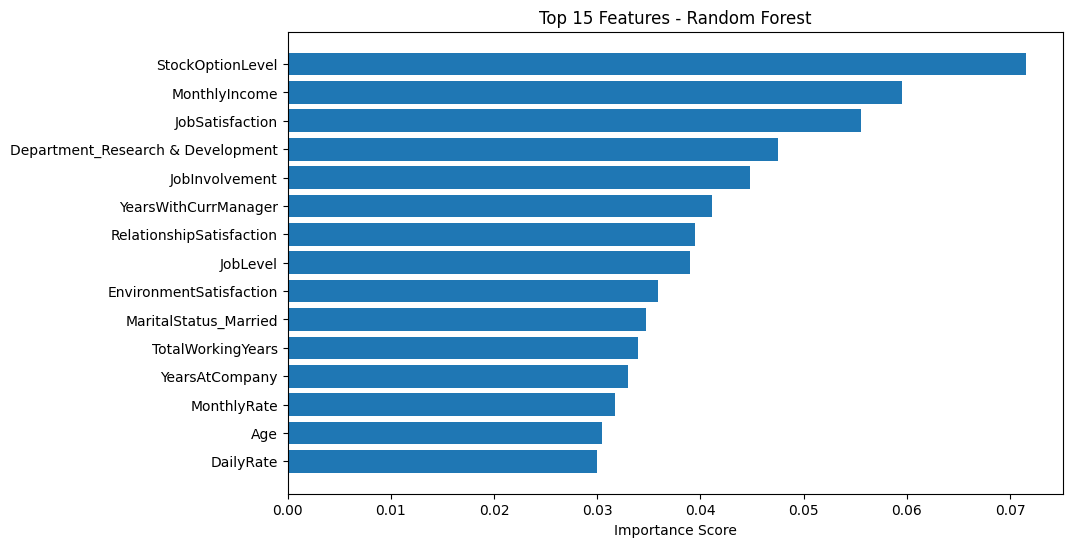


Top 15 XGBoost Features
                              Feature  Importance
15                   StockOptionLevel    0.068724
26                   Department_Sales    0.068146
33            JobRole_Human Resources    0.056975
35                    JobRole_Manager    0.052144
40       JobRole_Sales Representative    0.049587
25  Department_Research & Development    0.043712
7                            JobLevel    0.039534
30               EducationField_Other    0.037986
29             EducationField_Medical    0.037656
6                      JobInvolvement    0.030131
31    EducationField_Technical Degree    0.029504
36     JobRole_Manufacturing Director    0.029420
41              MaritalStatus_Married    0.026685
34      JobRole_Laboratory Technician    0.025293
28           EducationField_Marketing    0.024999


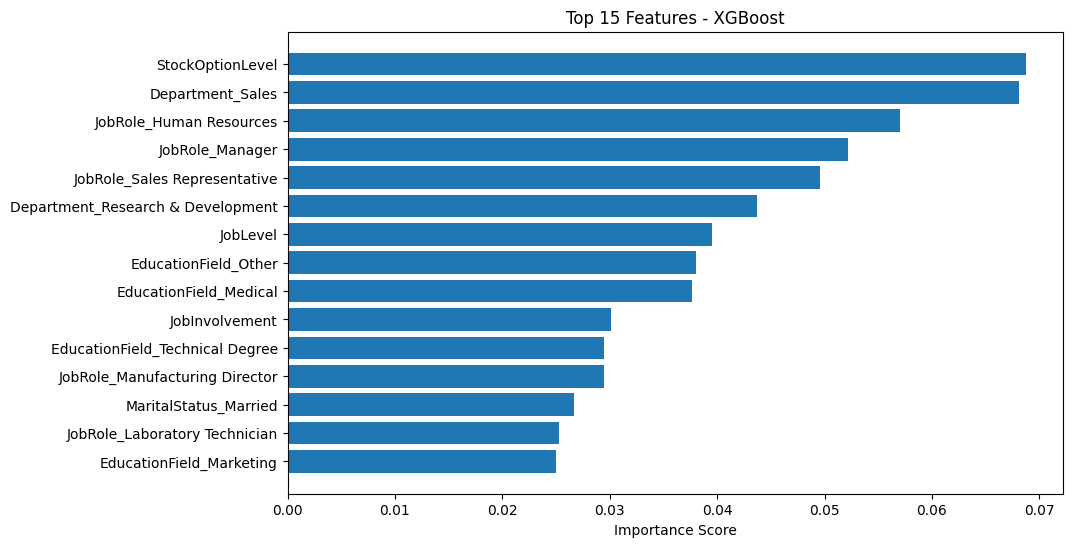


Feature importance files saved successfully.


In [2]:
# ==========================================================
# Employee Attrition Analysis - Phase 8
# Feature Importance and Business Insights
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

# ----------------------------------------------------------
# Load Dataset and Models
# ----------------------------------------------------------

df = pd.read_csv("/content/employee_attrition_processed_EDA.csv")

rf_model = joblib.load("random_forest_attrition.pkl")
xgb_model = joblib.load("xgboost_attrition.pkl")

# ----------------------------------------------------------
# Separate Features and Target
# ----------------------------------------------------------

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# ----------------------------------------------------------
# Random Forest Feature Importance
# ----------------------------------------------------------

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Random Forest Features")
print(rf_importance.head(15))

# ----------------------------------------------------------
# Plot Random Forest Importance
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    rf_importance["Feature"].head(15),
    rf_importance["Importance"].head(15)
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

# ----------------------------------------------------------
# XGBoost Feature Importance
# ----------------------------------------------------------

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 XGBoost Features")
print(xgb_importance.head(15))

# ----------------------------------------------------------
# Plot XGBoost Importance
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    xgb_importance["Feature"].head(15),
    xgb_importance["Importance"].head(15)
)

plt.title("Top 15 Features - XGBoost")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

# ----------------------------------------------------------
# Save Importance Files
# ----------------------------------------------------------

rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print("\nFeature importance files saved successfully.")